## Hybrid Keyword Extraction (TF-IDF Weighted Word2Vec)

This notebook implements an advanced hybrid NLP pipeline that combines statistical importance (TF-IDF) with neural semantic embeddings (Word2Vec) to extract high-fidelity technical keywords from NIPS research papers.

##### Environment Setup & Component Loading
* Loading preprocessed scientific text.
* Importing the trained Word2Vec Skip-gram model.
* Loading the TF-IDF Vectorizer and Sparse Matrix.

##### Methodology: Solving the "Bias of the Mean".

In [1]:
import pandas as pd
import ast

papers = pd.read_csv('../data/papers_preprocessed.csv')
papers['lemmatized_tokens'] = papers['lemmatized_tokens'].apply(ast.literal_eval)

In [2]:
from gensim.models import Word2Vec

w2v_model = Word2Vec.load('../models/word2vec_nips.model')
print("Word2Vec model loaded successfully.")

Word2Vec model loaded successfully.


In [3]:
import joblib

vectorizer = joblib.load('../models/tfidf_vectorizer.pkl')
tfidf_matrix = joblib.load('../models/tfidf_matrix.pkl')

In [4]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def get_weighted_doc_vector(tokens, model, tfidf_scores):
    vectors = []
    weights = []
    
    for t in tokens:
        if t in model.wv and t in tfidf_scores:
            vectors.append(model.wv[t])
            weights.append(tfidf_scores[t])
            
    if not vectors:
        return None
    
    weighted_sum = np.sum([v * w for v, w in zip(vectors, weights)], axis=0)
    return weighted_sum / np.sum(weights)

def get_w2v_tfidf_keywords(tokens, paper_index, model, tfidf_vectorizer, tfidf_matrix, top_n=5):
    feature_names = tfidf_vectorizer.get_feature_names_out()
    current_tfidf_row = tfidf_matrix[paper_index].toarray().flatten()
    
    tfidf_scores = {feature_names[i]: current_tfidf_row[i] 
                    for i in range(len(feature_names)) if current_tfidf_row[i] > 0}

    doc_vector = get_weighted_doc_vector(tokens, model, tfidf_scores)
    if doc_vector is None: 
        return []

    unique_tokens = list(set([t for t in tokens if t in model.wv]))
    word_vectors = np.array([model.wv[t] for t in unique_tokens])
    similarities = cosine_similarity(doc_vector.reshape(1, -1), word_vectors)[0]

    scored = sorted(zip(unique_tokens, similarities), key=lambda x: x[1], reverse=True)

    final_keywords = []
    for word, score in scored:
        if len(word) > 2:
            final_keywords.append(word)

        if len(final_keywords) == top_n:
            break

    return final_keywords

In [5]:
print("Extracting Hybrid Keywords...")

papers['hybrid_keywords'] = [
    get_w2v_tfidf_keywords(
        tokens=papers['lemmatized_tokens'].iloc[i], 
        paper_index=i, 
        model=w2v_model, 
        tfidf_vectorizer=vectorizer, 
        tfidf_matrix=tfidf_matrix
    ) for i in range(len(papers))
]

Extracting Hybrid Keywords...


In [6]:
test_words = ['neural', 'optimization', 'classification', 'gradient']

for word in test_words:
    if word in w2v_model.wv:
        print(f"\nMost similar to '{word}':")
        for similar_word, score in w2v_model.wv.most_similar(word, topn=8):
            print(f"  {similar_word}: {score:.4f}")


Most similar to 'neural':
  neural_network: 0.6664
  iclr_srivastava: 0.6114
  neu_ral: 0.6061
  depthwidth_tradeoff: 0.6050
  deep_convolutional: 0.5997
  soudry_elyaniv: 0.5986
  chine_translation: 0.5977
  recurrent_hessianfree: 0.5970

Most similar to 'optimization':
  opti_mization: 0.8560
  optimiza_tion: 0.8448
  timization: 0.8059
  optimiza: 0.7194
  nonconvex_optimization: 0.7191
  sequential_modelbased: 0.6988
  expensivetoevaluate_function: 0.6889
  mockus: 0.6853

Most similar to 'classification':
  clas_sification: 0.8021
  classi_fication: 0.7748
  classifier: 0.7721
  classifica_tion: 0.7657
  classi_cation: 0.7649
  classifi_cation: 0.7477
  binary_classification: 0.6978
  clas_siﬁcation: 0.6823

Most similar to 'gradient':
  gradi_ent: 0.7764
  gra_dient: 0.7497
  gra_dients: 0.7249
  pgcn: 0.6726
  gradi_ents: 0.6590
  θlθ: 0.6501
  pathw_derivative: 0.6475
  prox_oracle: 0.6427


In [8]:
for i in [0, 5, 10, 20, 50]:
    paper_title = papers['title'].iloc[i] if 'title' in papers.columns else f"Paper {i}"
    keywords = papers['hybrid_keywords'].iloc[i]
    print(f"\nPaper {i}: {paper_title}")
    print(f"Keywords: {keywords}")


Paper 0: Bit-Serial Neural Networks
Keywords: ['receiv_ing', 'noise_immunity', 'excita_tion', 'satura_tion', 'interconnected_neuron']

Paper 5: A Neural-Network Solution to the Concentrator Assignment Problem
Keywords: ['neuron', 'strength_synapse', 'concentrator_assignment', 'tij_tji', 'jected']

Paper 10: Optimal Neural Spike Classification
Keywords: ['spike', 'spikes', 'neuron', 'action_potential', 'spike_neuron']

Paper 20: A Computer Simulation of Cerebral Neocortex: Computational Capabilities of Nonlinear Neural Networks
Keywords: ['finegrain_connectivity', 'confines', 'reponse', 'neuron', 'neurons']

Paper 50: Correlational Strength and Computational Algebra of Synaptic Connections Between Neurons
Keywords: ['disynaptic_link', 'monosynaptically', 'correlational_effect', 'polysynaptic', 'broadening']


C:\Users\Reem\AppData\Local\Temp\ipykernel_19320\1155241477.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Keyword', data=top20, palette='Blues_d')


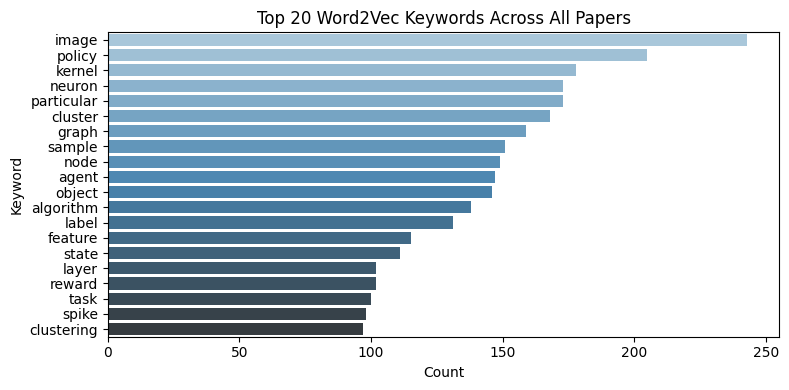

In [9]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.rcParams['figure.figsize'] = (8, 4)

all_hybrid_keywords = [kw for kws in papers['hybrid_keywords'] for kw in kws]
top20 = pd.DataFrame(
    Counter(all_hybrid_keywords).most_common(20),
    columns=['Keyword', 'Count']
)

sns.barplot(x='Count', y='Keyword', data=top20, palette='Blues_d')
plt.title('Top 20 Word2Vec Keywords Across All Papers')
plt.tight_layout()
plt.show()

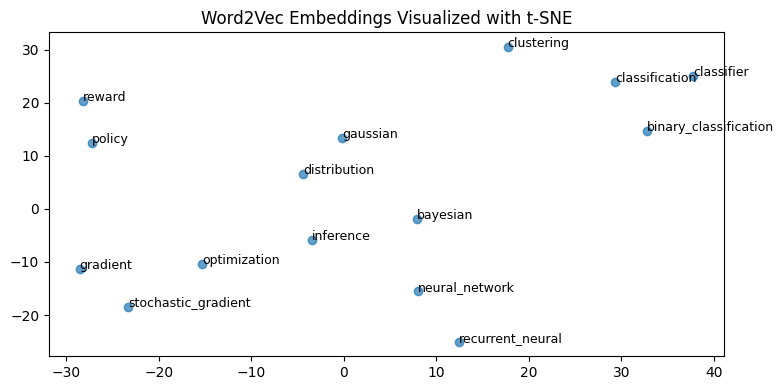

In [10]:
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt

focus_words = [
    'neural_network', 'deep_feedforward', 'recurrent_neural',
    'gradient', 'stochastic_gradient', 'optimization',
    'classification', 'classifier', 'binary_classification',
    'bayesian', 'probabilistic', 'inference',
    'reinforcement', 'policy', 'reward',
    'clustering', 'gaussian', 'distribution'
]

focus_words = [w for w in focus_words if w in w2v_model.wv]

vectors = np.array([w2v_model.wv[w] for w in focus_words])

tsne = TSNE(n_components=2, random_state=42, perplexity=5)
coords = tsne.fit_transform(vectors)

plt.figure(figsize=(8, 4))
plt.scatter(coords[:, 0], coords[:, 1], alpha=0.7)
for i, word in enumerate(focus_words):
    plt.annotate(word, (coords[i, 0], coords[i, 1]), fontsize=9)
plt.title('Word2Vec Embeddings Visualized with t-SNE')
plt.tight_layout()
plt.show()

- The transition from a simple average Word2Vec model to a TF-IDF weighted model successfully eliminated "metadata noise" (author names and affiliations), centering the keywords on actual research topics.
- The TF-IDF Baseline was excellent at finding rare words, the Advanced Hybrid Model captured deep semantic relationships, identifying technical concepts that are contextually central to the paper’s theme.

In [11]:
import json

with open('../results/hybrid_w2v_results.json', 'w') as f:
    json.dump(papers['hybrid_keywords'].tolist(), f)
